In [108]:
# from google.colab import drive
# drive.mount('/content/drive')

In [109]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

#  Importing Libraries

In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string
import re
import datetime

from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve , auc, RocCurveDisplay

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Loading and viewing data

In [111]:
data=pd.read_csv("/content/drive/MyDrive/ml_data/recipe_ratings_train.csv")

In [112]:
data.shape  # no.of rows and columns present

(13636, 15)

In [113]:
data.columns

Index(['ID', 'RecipeNumber', 'RecipeCode', 'RecipeName', 'CommentID', 'UserID',
       'UserName', 'UserReputation', 'CreationTimestamp', 'ReplyCount',
       'ThumbsUpCount', 'ThumbsDownCount', 'Rating', 'BestScore',
       'Recipe_Review'],
      dtype='object')

In [114]:
data.head()

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
0,70,71,12259,Banana Bars with Cream Cheese Frosting,sp_aUSaElGf_12259_c_149978,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622717078,0,0,0,5,100,great recipe! I have made them just as written...
1,72,88,8202,Simple Taco Soup,sp_aUSaElGf_8202_c_310332,u_1oKZeRIXYzGNhGW8OMR3O4lX1ih,MichelleMalone,1,1622717852,0,0,1,5,100,This is an easy and quick recipe that is great...
2,458,3,2832,Cheeseburger Soup,sp_aUSaElGf_2832_c_206522,u_1oKYHUtdaD48KJCDYq5wfpAUxWz,jeannem32,1,1622717357,0,0,0,3,100,I think I was looking for something extra spec...
3,7,50,100276,Grilled Huli Huli Chicken,sp_aUSaElGf_100276_c_434088,u_1oKZCQcKQZdQhDVBS7oISc216VA,ds422,1,1622648899,0,0,0,5,100,This is our favorite grilled chicken recipe. ...
4,60,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_387011,u_1oKd4sudZQPgu6YALiC7bW7mKMs,SusanHoward,1,1622718260,0,0,0,4,100,Great basic recipe. I added 2 teaspoons Tuscan...


In [115]:
data.info()   #checking for datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13636 entries, 0 to 13635
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 13636 non-null  int64 
 1   RecipeNumber       13636 non-null  int64 
 2   RecipeCode         13636 non-null  int64 
 3   RecipeName         13636 non-null  object
 4   CommentID          13636 non-null  object
 5   UserID             13636 non-null  object
 6   UserName           13636 non-null  object
 7   UserReputation     13636 non-null  int64 
 8   CreationTimestamp  13636 non-null  int64 
 9   ReplyCount         13636 non-null  int64 
 10  ThumbsUpCount      13636 non-null  int64 
 11  ThumbsDownCount    13636 non-null  int64 
 12  Rating             13636 non-null  int64 
 13  BestScore          13636 non-null  int64 
 14  Recipe_Review      13634 non-null  object
dtypes: int64(10), object(5)
memory usage: 1.6+ MB


In [116]:
#converting unix CreationTimestamp to time date format
data['CreationTimestamp'] = pd.to_datetime(
    data['CreationTimestamp'],
    unit='s'
)

In [117]:
data.isnull().sum()  #checking for null values

,0
ID,0
RecipeNumber,0
RecipeCode,0
RecipeName,0
CommentID,0
UserID,0
UserName,0
UserReputation,0
CreationTimestamp,0
ReplyCount,0


In [118]:
Percentage=data['Recipe_Review'].isnull().sum()/data.shape[0]
Percentage

np.float64(0.00014667057788207686)

the missing values might not be very informative due to the small proportion of missing data so we can drop those values

In [119]:
data.dropna(inplace=True) #dropping null values

In [120]:
data.describe(include='all') #Statistical summary

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
count,13634.00000,13634.000000,13634.000000,13634,13634,13634,13634,13634.000000,13634,13634.000000,13634.000000,13634.000000,13634.000000,13634.00000,13634
unique,NaN,NaN,NaN,100,13634,10782,10619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13370
top,NaN,NaN,NaN,Cheeseburger Soup,sp_aUSaElGf_2832_c_278956,u_1oKVZoIOMWJ2j7TA7py2BIbf1mm,mjlouk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Delicious!
freq,NaN,NaN,NaN,552,1,20,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
mean,121.05589,38.629382,21787.406117,NaN,NaN,NaN,NaN,2.160481,2021-06-14 23:32:35.414845184,0.014523,1.098430,0.543788,4.288617,153.13569,NaN
min,0.00000,1.000000,386.000000,NaN,NaN,NaN,NaN,0.000000,2021-02-11 09:22:16,0.000000,0.000000,0.000000,0.000000,0.00000,NaN
25%,45.00000,12.000000,6504.000000,NaN,NaN,NaN,NaN,1.000000,2021-06-03 10:47:22,0.000000,0.000000,0.000000,5.000000,100.00000,NaN
50%,91.00000,33.000000,14600.000000,NaN,NaN,NaN,NaN,1.000000,2021-06-03 10:55:07,0.000000,0.000000,0.000000,5.000000,100.00000,NaN
75%,148.00000,63.000000,33121.000000,NaN,NaN,NaN,NaN,1.000000,2021-06-03 11:02:52,0.000000,0.000000,0.000000,5.000000,100.00000,NaN
max,724.00000,100.000000,191775.000000,NaN,NaN,NaN,NaN,510.000000,2022-10-14 14:00:35,3.000000,80.000000,126.000000,5.000000,946.00000,NaN


* most frequent value in the RecipeName column is "Cheeseburger Soup", which appears 552 times.
* the minimum rating is 0 and maximum rating is 5.
* each user is associated with only one or a few recipes.


# Cheking Distribution of Rating Data(Target variable)

In [121]:
data['Rating'].unique()

array([5, 3, 4, 0, 2, 1])

In [122]:
data['Rating'].value_counts()

,count
Rating,
5,10369
0,1272
4,1241
3,368
1,210
2,174


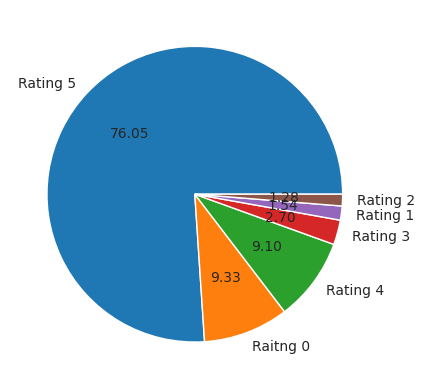

In [123]:
plt.pie(data['Rating'].value_counts(),labels=['Rating 5','Raitng 0','Rating 4','Rating 3','Rating 1','Rating 2'], autopct='%0.2f')
plt.show()

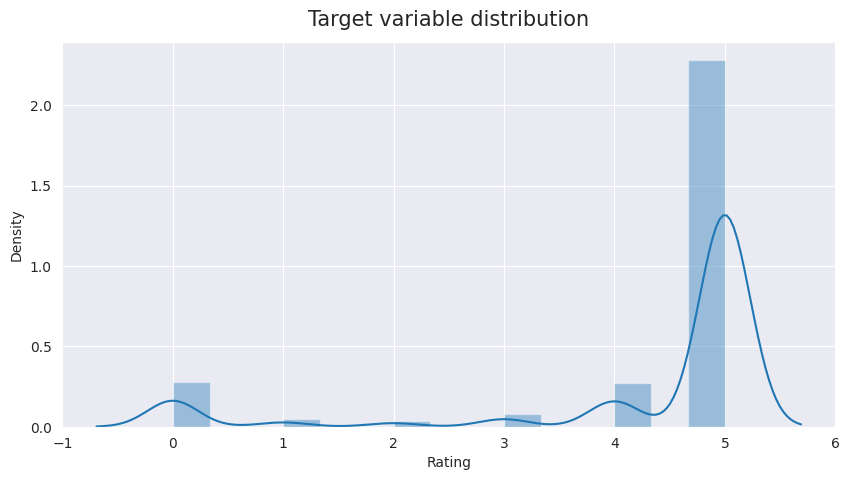

None

np.float64(-2.1282029504008753)

In [124]:
sns.set_style('darkgrid')
plt.figure(figsize = (10, 5))
sns.distplot(data.Rating, kde = True, bins = 15)
plt.title('Target variable distribution', y = 1.02, fontsize = 15)
display(plt.show(), data.Rating.skew())

1. A negative skewness value indicates that the distribution is skewed towards left

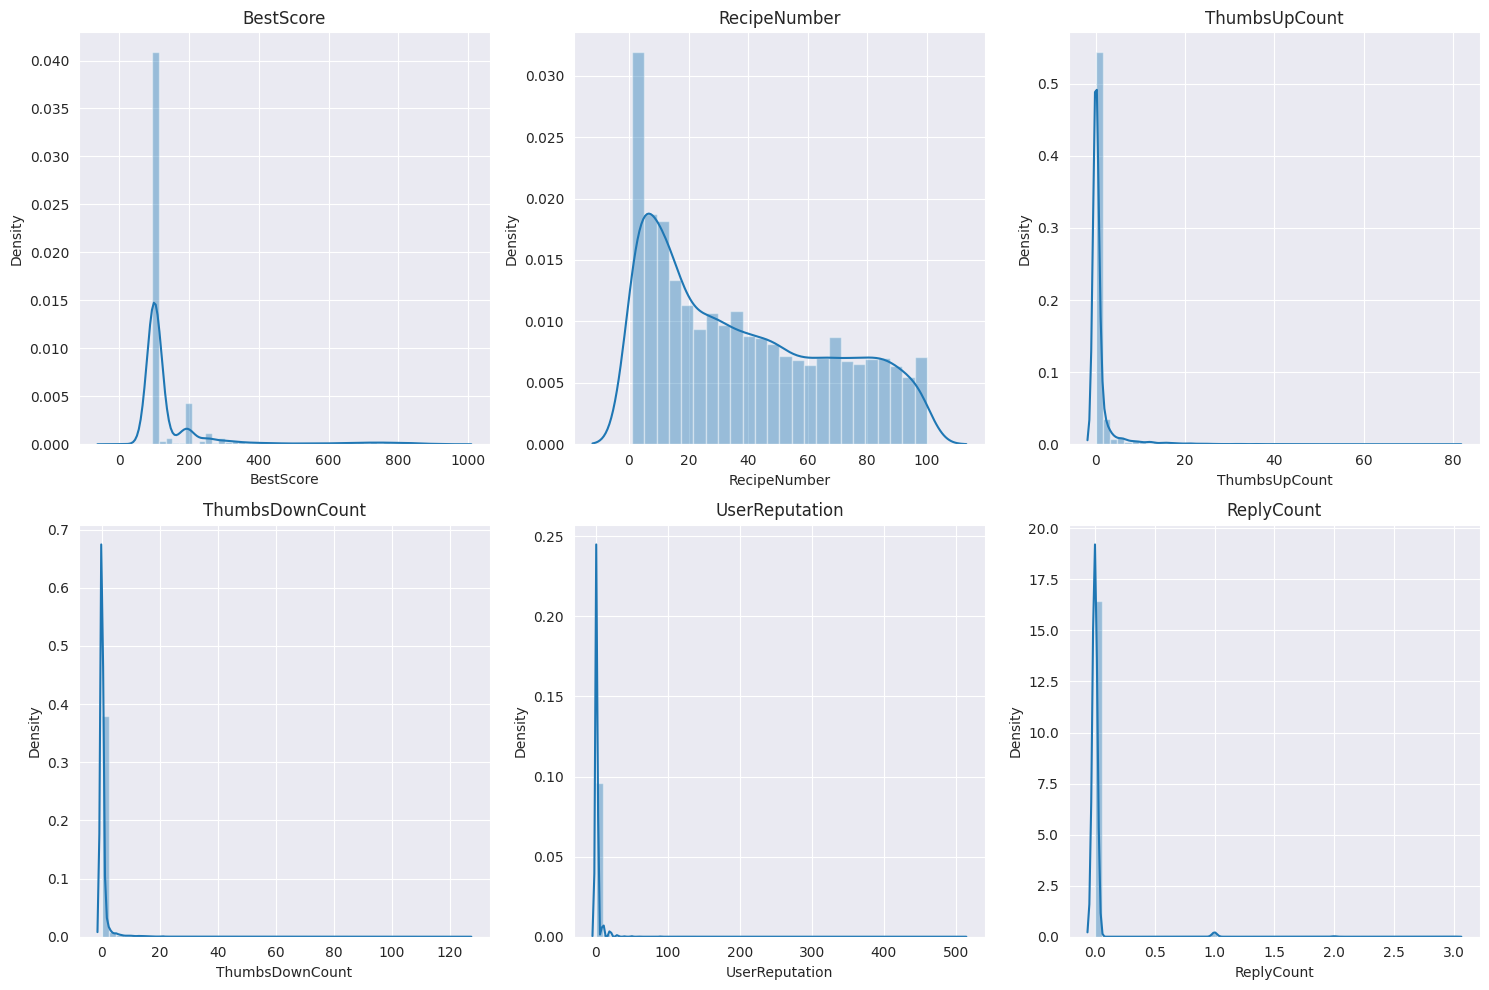

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution plot
columns = ['BestScore', 'RecipeNumber', 'ThumbsUpCount', 'ThumbsDownCount', 'UserReputation', 'ReplyCount']

num_plots = len(columns)
num_cols = min(num_plots, 3)  # Display up to 3 plots per row
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows)) # Creating subplots for each column

for i, column in enumerate(columns):
    sns.distplot(data[column], ax=axes[i//num_cols, i%num_cols])  # Accessing subplot using row and column indices
    axes[i//num_cols, i%num_cols].set_title(column)

plt.tight_layout()
plt.show()


* from the above graph we can say that data is right skewed

# Checking Outliers

<Axes: ylabel='Rating'>

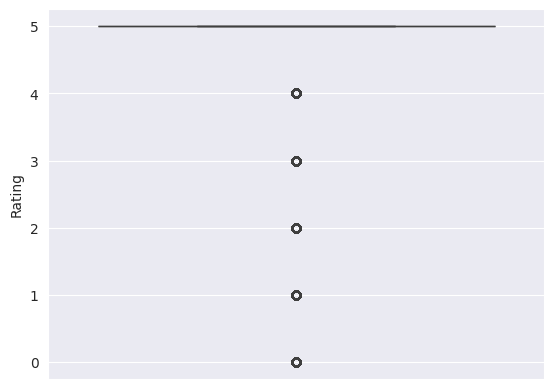

In [126]:
sns.boxplot(data['Rating'])

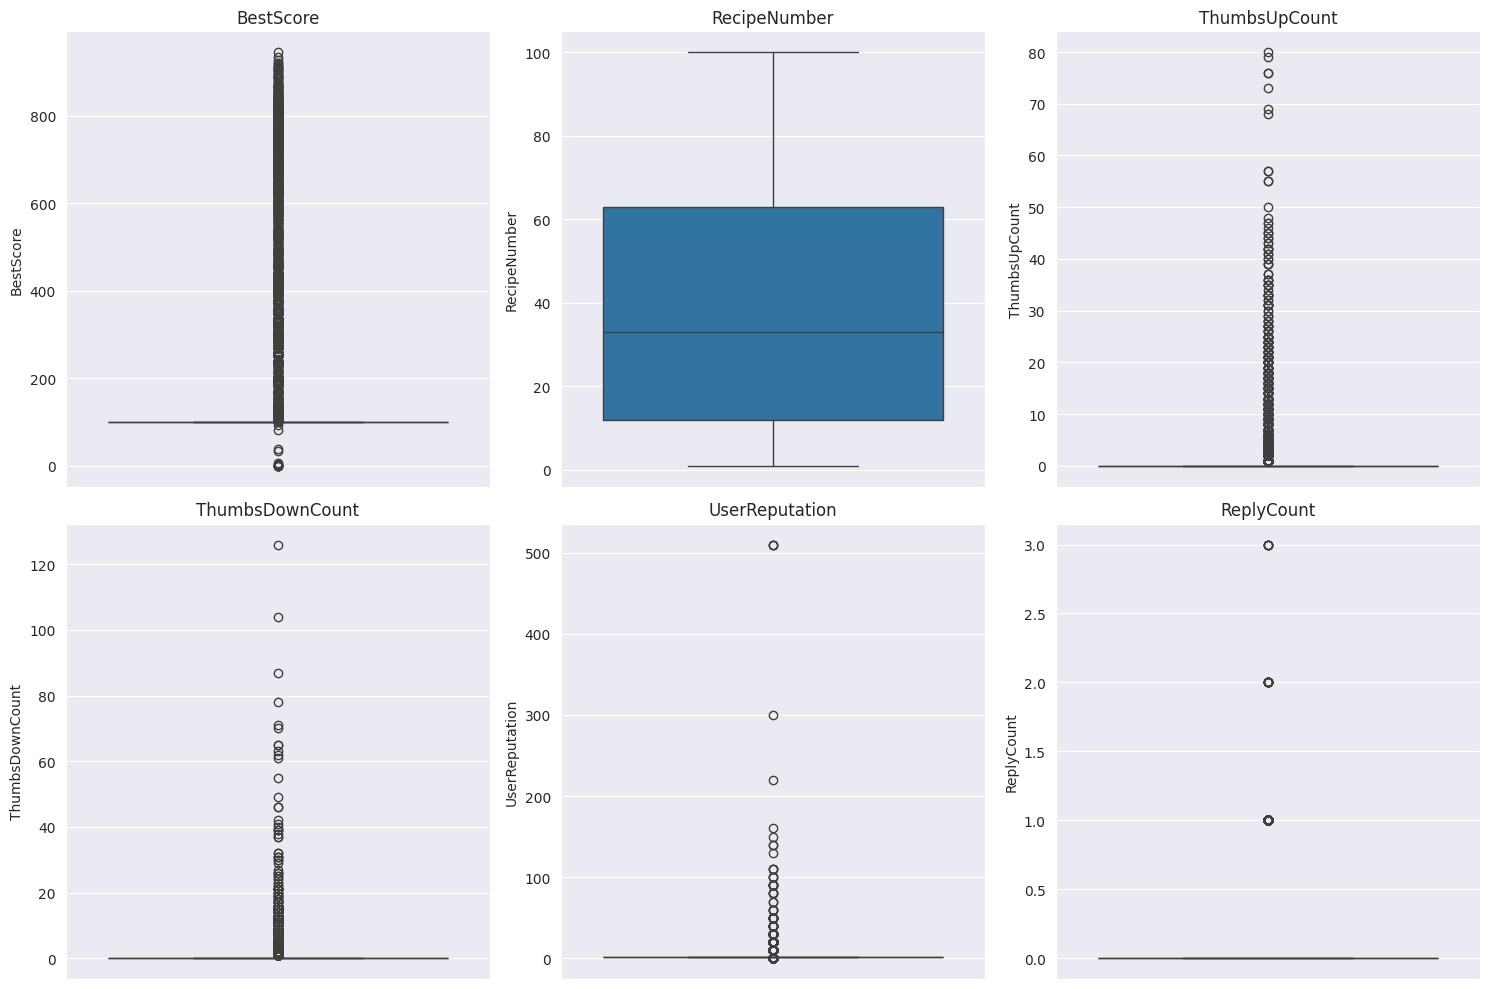

In [127]:
columns = ['BestScore', 'RecipeNumber', 'ThumbsUpCount', 'ThumbsDownCount', 'UserReputation', 'ReplyCount']

num_plots = len(columns)
num_cols = min(num_plots, 3)  # Display up to 3 plots per row
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows)) # Creating subplots for each column

for i, column in enumerate(columns):
    sns.boxplot(data[column], ax=axes[i//num_cols, i%num_cols])  # Accessing subplot using row and column indices
    axes[i//num_cols, i%num_cols].set_title(column)

plt.tight_layout()
plt.show()


# Correlation

<Axes: >

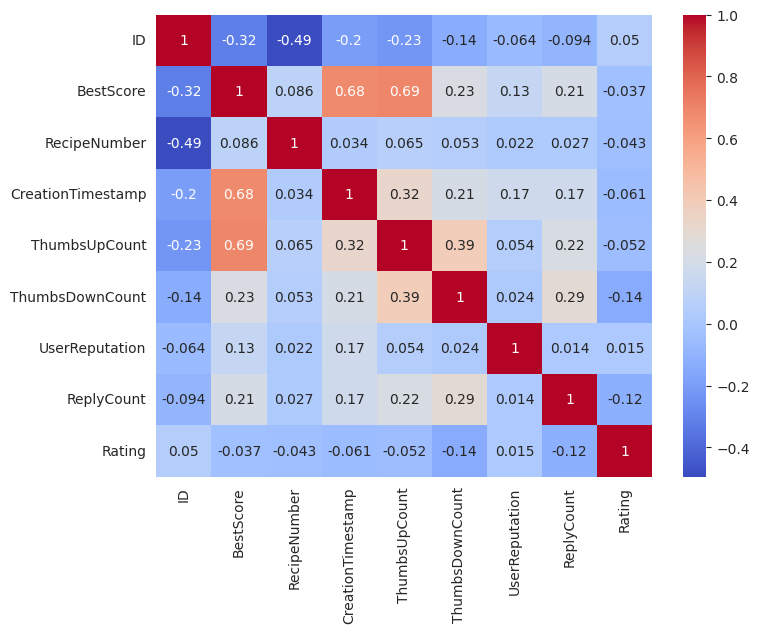

In [128]:
numeric_features =['ID',
                   'BestScore',
                   'RecipeNumber',
                   'CreationTimestamp',
                   'ThumbsUpCount',
                   'ThumbsDownCount',
                   'UserReputation',
                   'ReplyCount',
                   'Rating']
corre= data[numeric_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corre, annot = True, cmap = 'coolwarm')   # correlation Heat Map

* Their is high correlation between CreationTimestamp, BestScore, ThumbsUpCount


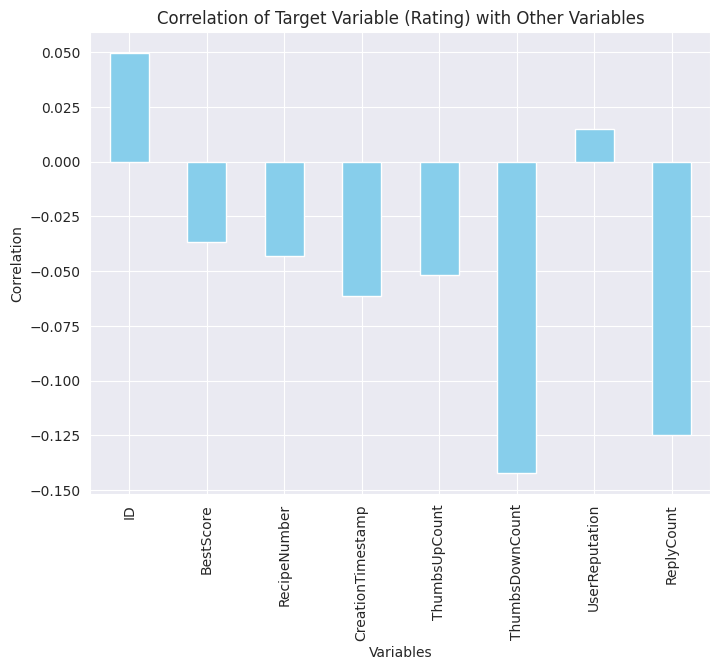

In [129]:
target_correlation = corre['Rating']
plt.figure(figsize=(8, 6))
target_correlation.drop('Rating').plot(kind='bar', color='skyblue')
plt.title('Correlation of Target Variable (Rating) with Other Variables')
plt.xlabel('Variables')
plt.ylabel('Correlation')
plt.show()


In [130]:
top_rated = (                               # Finding recipes which has highest ratings
    data.groupby('RecipeName')['Rating']
    .mean()
    .sort_values(ascending=False)
)

top_rated.head(10)

,Rating
RecipeName,
Rustic Italian Tortellini Soup,4.739336
Corn Pudding,4.692308
Zucchini Pizza Casserole,4.657371
Comforting Chicken Noodle Soup,4.654321
Special Banana Nut Bread,4.648936
Pumpkin Bread,4.639706
Vegetarian Linguine,4.631579
Cheeseburger Soup,4.623188
Macaroni Coleslaw,4.608392


In [131]:
least_liked = (                            # Finding recipes which has lowest ratings
    data.groupby('RecipeName')['Rating']
    .mean()
    .sort_values(ascending=True)
)

least_liked.head(10)

,Rating
RecipeName,
Pineapple Orange Cake,2.682759
Fluffy Key Lime Pie,2.740000
Caramel Heavenlies,3.125000
Peanut Butter Cup Cheesecake,3.768116
Flavorful Pot Roast,3.774194
Li’l Cheddar Meat Loaves,3.783069
Caramel-Pecan Cheesecake Pie,3.786260
Twice-Baked Potato Casserole,3.825581
Lime Chicken Tacos,3.861538


In [132]:
columns=['ID','CommentID','UserName','UserID','BestScore'] # dropping columns
data=data.drop(columns=columns)

CommentID,UserName,UserId might not be usefull for predicting Rating
as each user will be associated will only one or few recipes.

CreationTimestamp,BestScore have positive correlation with ThumbsUpCount

In [133]:
data.head()

,RecipeNumber,RecipeCode,RecipeName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,Recipe_Review
0,71,12259,Banana Bars with Cream Cheese Frosting,20,2021-06-03 10:44:38,0,0,0,5,great recipe! I have made them just as written...
1,88,8202,Simple Taco Soup,1,2021-06-03 10:57:32,0,0,1,5,This is an easy and quick recipe that is great...
2,3,2832,Cheeseburger Soup,1,2021-06-03 10:49:17,0,0,0,3,I think I was looking for something extra spec...
3,50,100276,Grilled Huli Huli Chicken,1,2021-06-02 15:48:19,0,0,0,5,This is our favorite grilled chicken recipe. ...
4,12,19731,Cauliflower Soup,1,2021-06-03 11:04:20,0,0,0,4,Great basic recipe. I added 2 teaspoons Tuscan...


# Text Preprocessing

In [134]:
def clean_text(text):
    if not isinstance(text, str):  # Checking if non-string (e.g., NaN)
        return ''

    text = text.lower()  # Converting to lowercase

    text = re.sub(r'http\S+', '', text)  # Removing links
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Removing punctuation

    return text

data['Recipe_Review'] = data['Recipe_Review'].apply(clean_text)


In [135]:
data['Recipe_Review']

,Recipe_Review
0,great recipe i have made them just as written ...
1,this is an easy and quick recipe that is great...
2,i think i was looking for something extra spec...
3,this is our favorite grilled chicken recipe g...
4,great basic recipe i added teaspoons tuscan s...
...,...
13631,delicious very easy to make one minor change ...
13632,i made this pie for my family and they loved i...
13633,very tasty
13634,i have made this numerous times its so good a...


In [136]:
#!pip install textblob
from textblob import TextBlob

In [137]:
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

In [138]:
data['sentiment_polarity'] = data['Recipe_Review'].apply(get_polarity)

data['sentiment_subjectivity'] = data['Recipe_Review'].apply(get_subjectivity)

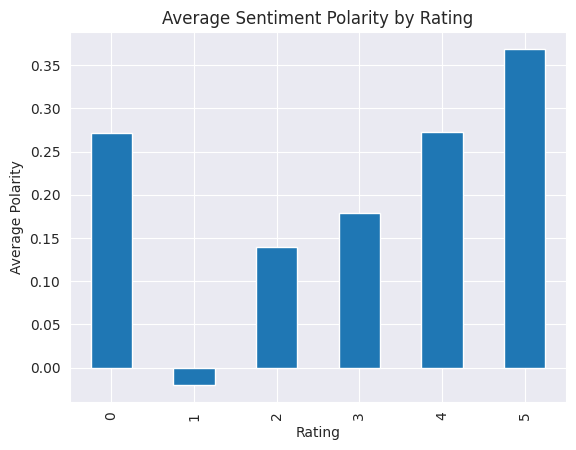

In [139]:
avg_sentiment = data.groupby('Rating')[
    'sentiment_polarity'
].mean()

avg_sentiment.plot(kind='bar')

plt.title('Average Sentiment Polarity by Rating')

plt.ylabel('Average Polarity')

plt.show()

In [140]:
data['review_length'] = data['Recipe_Review'].apply(
    lambda x: len(str(x))
)

In [141]:
data['word_count'] = data['Recipe_Review'].apply(
    lambda x: len(str(x).split())
)

<Axes: >

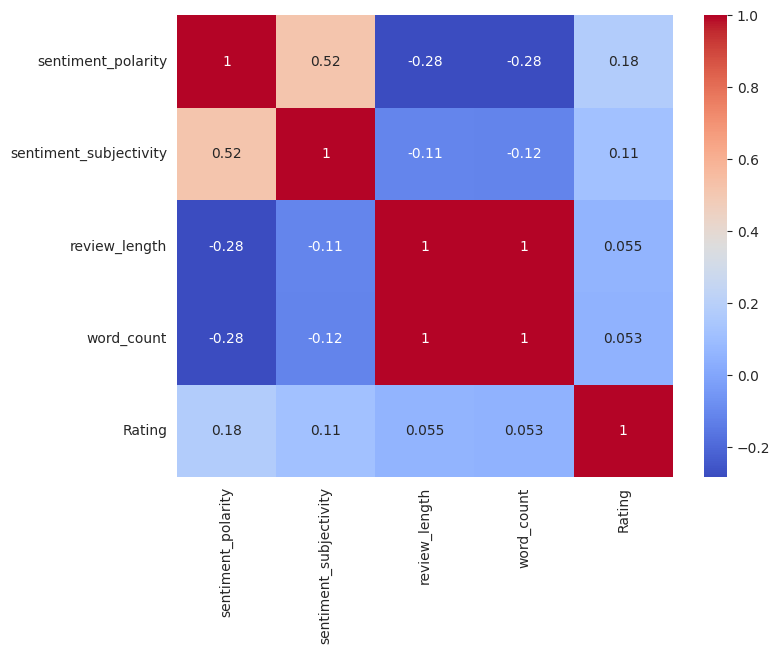

In [142]:
features_corr = [
    'sentiment_polarity',
    'sentiment_subjectivity',
    'review_length',
    'word_count',
    'Rating'
]
corre= data[features_corr].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corre, annot = True, cmap = 'coolwarm')

# Encoding RecipeName

In [143]:
encoder = LabelEncoder()
data["RecipeName"]=encoder.fit_transform(data["RecipeName"])
RecipeName_no={ index: label for index, label in enumerate(encoder.classes_)}
RecipeName_no

{0: 'Amish Breakfast Casserole',
 1: 'Apple Pie',
 2: 'Asian Chicken Thighs',
 3: 'Bacon Macaroni Salad',
 4: 'Baked Mushroom Chicken',
 5: 'Baked Spaghetti',
 6: 'Baked Tilapia',
 7: 'Banana Bars with Cream Cheese Frosting',
 8: 'Basic Banana Muffins',
 9: 'Basic Homemade Bread',
 10: 'Best Ever Banana Bread',
 11: 'Best Ever Potato Soup',
 12: 'Big Soft Ginger Cookies',
 13: 'Black Bean ‘n’ Pumpkin Chili',
 14: 'Blueberry French Toast',
 15: 'Brown Sugar Oatmeal Pancakes',
 16: 'Bruschetta Chicken',
 17: 'Buttery Cornbread',
 18: 'Caramel Heavenlies',
 19: 'Caramel-Pecan Cheesecake Pie',
 20: 'Cauliflower Soup',
 21: 'Cheeseburger Paradise Soup',
 22: 'Cheeseburger Soup',
 23: 'Cheesy Ham Chowder',
 24: 'Cherry Bars',
 25: 'Chicken Penne Casserole',
 26: 'Chicken Wild Rice Soup',
 27: 'Chicken and Dumplings',
 28: 'Chocolate Caramel Candy',
 29: 'Chocolate Chip Oatmeal Cookies',
 30: 'Chocolate Guinness Cake',
 31: 'Chocolate-Strawberry Celebration Cake',
 32: 'Chunky Apple Cake',
 3

# OOT Validation

In [144]:
data = data.sort_values('CreationTimestamp')

In [145]:
train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    shuffle=False
)

In [146]:
print("Train Range:")
print(
    train_data['CreationTimestamp'].min(),
    "to",
    train_data['CreationTimestamp'].max()
)

print()

print("Test Range:")
print(
    test_data['CreationTimestamp'].min(),
    "to",
    test_data['CreationTimestamp'].max()
)

Train Range:
2021-02-11 09:22:16 to 2021-06-03 11:04:18

Test Range:
2021-06-03 11:04:18 to 2022-10-14 14:00:35


In [147]:
X_train = train_data.drop(columns=['Rating'])

y_train = train_data['Rating']

X_test = test_data.drop(columns=['Rating'])

y_test = test_data['Rating']

In [148]:
X_train = X_train.drop(columns=['CreationTimestamp'])

X_test = X_test.drop(columns=['CreationTimestamp'])

In [149]:
X_train

,RecipeNumber,RecipeCode,RecipeName,UserReputation,ReplyCount,ThumbsUpCount,ThumbsDownCount,Recipe_Review,sentiment_polarity,sentiment_subjectivity,review_length,word_count
13272,1,14299,39,1,0,0,0,pa favorite of my hubby he loves the flavor of...,0.500000,1.000000,68,16
9403,68,74724,30,1,0,0,0,pany ideas for nonalcoholic substitute for the...,0.000000,0.000000,67,11
12416,41,35948,19,1,0,0,0,pi have made this pie a few times and my famil...,0.412500,0.508333,295,56
8338,100,82745,63,1,0,0,0,pi received endless compliments on this cake i...,0.031250,0.650000,289,55
2497,22,1081,5,1,0,0,0,pmy husband and i really enjoyed this baked sp...,0.175000,0.586111,336,65
...,...,...,...,...,...,...,...,...,...,...,...,...
4856,3,2832,22,1,0,12,0,first time i made this i found the velveeta ma...,0.201389,0.362963,553,107
2507,20,6504,65,1,0,1,6,i always add diced bell peppers to my meatloaf...,0.100000,0.100000,109,20
2014,31,7708,8,1,0,0,0,i am allergic to eggs and gluten i made these ...,0.600000,0.750000,265,52
2660,7,12540,47,1,0,0,0,i am from south texas and this is the best faj...,0.186667,0.596667,178,37


# Splitting Dataset into train and test data

In [150]:
# X=data.drop('Rating', axis=1)
# y=data['Rating']
# X.shape, y.shape

In [151]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.20,
#     shuffle=True,
#     stratify=y
#     random_state=42
#     )
# X_train.shape, X_test.shape

In [152]:
X_train_num=X_train.drop('Recipe_Review',axis=1)
X_test_num=X_test.drop('Recipe_Review',axis=1)

In [153]:
X_train_txt=X_train['Recipe_Review']
X_test_txt=X_test['Recipe_Review']
X_train_txt

,Recipe_Review
13272,pa favorite of my hubby he loves the flavor of...
9403,pany ideas for nonalcoholic substitute for the...
12416,pi have made this pie a few times and my famil...
8338,pi received endless compliments on this cake i...
2497,pmy husband and i really enjoyed this baked sp...
...,...
4856,first time i made this i found the velveeta ma...
2507,i always add diced bell peppers to my meatloaf...
2014,i am allergic to eggs and gluten i made these ...
2660,i am from south texas and this is the best faj...


# Converting text data into numerical data

In [154]:
#Using TF- IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
X_train_txt_vec=vectorizer.fit_transform(X_train_txt)
X_test_txt_vec=vectorizer.transform(X_test_txt)
X_train_txt_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 166803 stored elements and shape (10907, 10791)>

In [155]:
X_train_txt_vec[1].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]])

In [156]:
feature_names = vectorizer.get_feature_names_out()
feature_names

array(['aa', 'aaahs', 'aback', ..., 'zucs', 'zucsp', 'zuke'], dtype=object)

# Finding important words from user reviews which has impact on ratings

In [157]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_txt_vec, y_train)

LogisticRegression(max_iter=1000)

In [158]:
coefficients = lr_model.coef_

In [159]:
positive_class_idx = list(lr_model.classes_).index(5)

positive_coeffs = coefficients[
    positive_class_idx
]

In [160]:
top_positive_idx = positive_coeffs.argsort()[-50:]

top_positive_words = [
    feature_names[i]
    for i in top_positive_idx
]

top_positive_scores = [
    positive_coeffs[i]
    for i in top_positive_idx
]

In [161]:
for word, score in zip(
    top_positive_words,
    top_positive_scores
):
    print(word, ":", score)

easy : 1.0772019103944968
second : 1.0822964921623586
definitely : 1.0875573232477367
summer : 1.0942099053699448
requested : 1.1047963944983765
place : 1.1270780758084085
olive : 1.1335457134536069
rhubarb : 1.1348604293385602
fajitas : 1.1429634342134798
favorites : 1.1479565185262899
incredible : 1.156325745345092
change : 1.1651872177550535
wow : 1.1700530599999026
usually : 1.1947329641657283
banana : 1.2042208799854268
year : 1.2175121259972317
celery : 1.2244542438218344
baby : 1.232252023710108
makes : 1.272164493154619
friends : 1.277591848404997
chopped : 1.2828960075454352
tsp : 1.2900205345754086
times : 1.2914612242594223
day : 1.3002842835122108
husband : 1.3006376296497144
home : 1.3335223088211128
yummy : 1.3428381953285198
potluck : 1.348008434256459
years : 1.3883083804177054
loves : 1.419463179483428
hand : 1.4687546180921756
hit : 1.5060859955049049
yum : 1.5420745657597712
favorite : 1.6529920941984146
family : 1.760736955948903
love : 1.8248399672249522
fabulous :

In [162]:
top_negative_idx = positive_coeffs.argsort()[:50]

top_negative_words = [
    feature_names[i]
    for i in top_negative_idx
]

top_negative_scores = [
    positive_coeffs[i]
    for i in top_negative_idx
]

for i in top_negative_idx:
    print(
        feature_names[i],
        ":",
        positive_coeffs[i]
    )

bland : -3.3919750444683636
ok : -2.6912455827171087
okay : -2.6628938515221385
care : -2.2629167770736762
wasnt : -2.077175200772189
thought : -1.9813420177870817
think : -1.9019250287033358
disappointed : -1.8764407918001313
dry : -1.8016045899619246
soggy : -1.7061722968010495
wrong : -1.6461532324488064
sorry : -1.6450134687540512
maybe : -1.6289251712179469
soupy : -1.624051209791624
sweet : -1.5998981641363628
waste : -1.5091103634605405
tasted : -1.4947893502495584
similar : -1.480293647231025
tortillas : -1.4512412408492175
sounds : -1.421055049359233
salty : -1.4080727073332615
runny : -1.395492795697246
needs : -1.3610577841981957
heavy : -1.3513426678785347
way : -1.3477917945471398
bad : -1.3440022022960267
pretty : -1.340625459653691
read : -1.2924868878379454
worst : -1.261407262718829
missing : -1.2588151194247161
isnt : -1.227768751138533
opinion : -1.2275235396922104
guinness : -1.2189282544667288
like : -1.2131219141076526
lot : -1.2033894061609487
taste : -1.19934853

In [163]:
positive_words = set(top_positive_words)

negative_words = set(top_negative_words)

In [164]:
def count_positive_words(text):

    words = str(text).lower().split()

    return sum(
        word in positive_words
        for word in words
    )

In [165]:
def count_negative_words(text):

    words = str(text).lower().split()

    return sum(
        word in negative_words
        for word in words
    )

In [166]:
X_train_num['positive_word_count'] = data[
    'Recipe_Review'
].apply(count_positive_words)

X_train_num['negative_word_count'] = data[
    'Recipe_Review'
].apply(count_negative_words)

X_test_num['positive_word_count'] = data[
    'Recipe_Review'
].apply(count_positive_words)

X_test_num['negative_word_count'] = data[
    'Recipe_Review'
].apply(count_negative_words)

In [167]:
X_train_num['net_sentiment_score'] = (
    X_train_num['positive_word_count']
    -
    X_train_num['negative_word_count']
)

X_test_num['net_sentiment_score'] = (
    X_test_num['positive_word_count']
    -
    X_test_num['negative_word_count']
)

# Scaling Numerical Features

In [168]:
ss=StandardScaler()
X_train_num_ss = pd.DataFrame( ss.fit_transform(X_train_num),columns=X_train_num.columns )
X_test_num_ss = pd.DataFrame( ss.transform(X_test_num),columns=X_test_num.columns )
X_train_num_ss.head()

,RecipeNumber,RecipeCode,RecipeName,UserReputation,ReplyCount,ThumbsUpCount,ThumbsDownCount,sentiment_polarity,sentiment_subjectivity,review_length,word_count,positive_word_count,negative_word_count,net_sentiment_score
0,-1.285726,-0.331672,-0.313656,-0.100433,-0.060058,-0.177474,-0.115598,0.567158,1.925218,-0.749940,-0.656506,-0.165455,0.209735,-0.268819
1,1.001760,2.275615,-0.622951,-0.100433,-0.060058,-0.177474,-0.115598,-1.260968,-2.593968,-0.756150,-0.818511,-1.272579,-0.624539,-0.757326
2,0.079937,0.602464,-1.000979,-0.100433,-0.060058,-0.177474,-0.115598,0.247236,-0.296715,0.659599,0.639538,1.495233,1.044009,0.708193
3,2.094290,2.621715,0.511131,-0.100433,-0.060058,-0.177474,-0.115598,-1.146710,0.343503,0.622342,0.607136,0.941670,-0.624539,1.196699
4,-0.568753,-0.902018,-1.482104,-0.100433,-0.060058,-0.177474,-0.115598,-0.621124,0.054777,0.914185,0.931147,0.388108,-0.624539,0.708193


# Combining both text data and numerical data

In [169]:
X_train_combined = np.hstack([X_train_num_ss,X_train_txt_vec.toarray()] )
X_test_combined = np.hstack([X_test_num_ss,X_test_txt_vec.toarray()] )
X_train_combined.shape

(10907, 10805)

# Model Building

# Logistic Regression

In [170]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_combined,y_train)

LogisticRegression(max_iter=1000)

In [171]:
print('Training Score:',lr.score(X_train_combined,y_train))

Training Score: 0.8224076281287247


In [172]:
y_pred = lr.predict(X_test_combined)
print('Testing Score:',lr.score(X_test_combined,y_test))

Testing Score: 0.7436743674367436


In [173]:
y_score_lr=lr.predict_proba(X_test_combined)
y_score_lr

array([[1.97633853e-01, 7.54866100e-03, 5.64995317e-03, 1.28106107e-02,
        7.43953106e-02, 7.01961612e-01],
       [2.46898024e-03, 4.42494110e-05, 1.20499209e-05, 1.29279098e-04,
        3.18541912e-02, 9.65491250e-01],
       [1.36662789e-01, 5.03763831e-01, 1.13752735e-01, 1.18393361e-01,
        8.67374204e-02, 4.06898640e-02],
       ...,
       [9.76918959e-02, 2.94065228e-03, 1.01594316e-02, 2.77338167e-02,
        3.71801756e-01, 4.89672448e-01],
       [3.00692737e-02, 4.02725872e-03, 7.94380388e-03, 2.16913267e-02,
        9.40404878e-02, 8.42227849e-01],
       [8.16673818e-02, 4.78645026e-02, 1.08530429e-01, 2.27133341e-01,
        3.95490179e-01, 1.39314166e-01]])

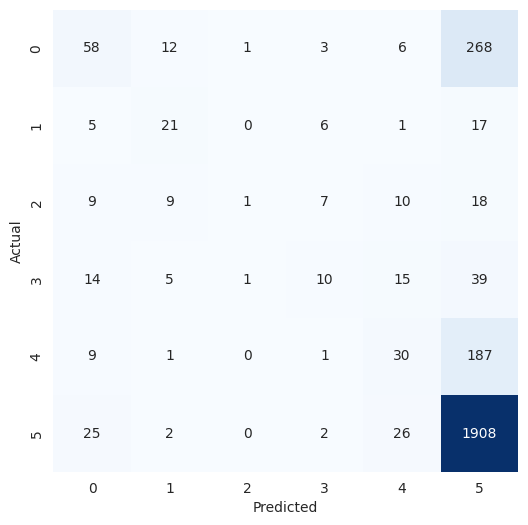

Classification Report:
-------------------
               precision    recall  f1-score   support

           0       0.48      0.17      0.25       348
           1       0.42      0.42      0.42        50
           2       0.33      0.02      0.04        54
           3       0.34      0.12      0.18        84
           4       0.34      0.13      0.19       228
           5       0.78      0.97      0.87      1963

    accuracy                           0.74      2727
   macro avg       0.45      0.30      0.32      2727
weighted avg       0.68      0.74      0.69      2727



In [174]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:\n-------------------\n', clr)

# LogisticRegression(with Hyperparameter)

In [175]:
# lr=LogisticRegression(max_iter=20000)
# param_grid= {'C': [0.01, 0.1, 1, 10, 100],
#             'penalty': ['l1','l2'],
#             'solver': ['lbfgs','liblinear','newton-cg'],
#             'multi_class':['auto','ovr']
#           }

# grid= GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
# grid.fit(X_train_combined, y_train)
# best_params = grid.best_params_
# best_params

In [176]:
lrhp=LogisticRegression(C=10,
                        penalty='l2',
                        solver='newton-cg',
                        multi_class='ovr')
lrhp.fit(X_train_combined,y_train)

LogisticRegression(C=10, multi_class='ovr', solver='newton-cg')

In [177]:
print('Training Score:',lrhp.score(X_train_combined,y_train))

Training Score: 0.9109746034656643


In [178]:
y_pred = lrhp.predict(X_test_combined)
print('Testing Score:',lrhp.score(X_test_combined,y_test))

Testing Score: 0.7414741474147415


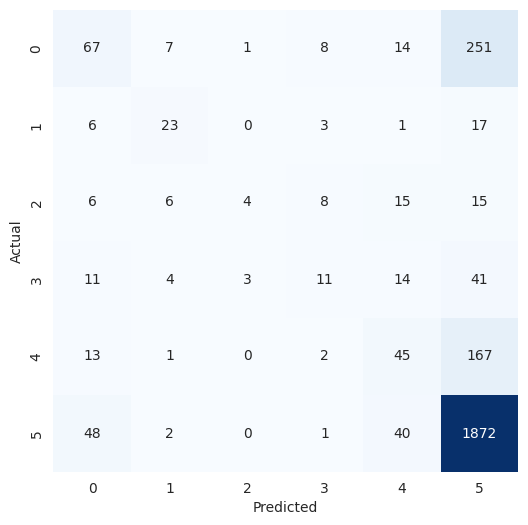

Classification Report:LogisticRegression
-------------------
               precision    recall  f1-score   support

           0       0.44      0.19      0.27       348
           1       0.53      0.46      0.49        50
           2       0.50      0.07      0.13        54
           3       0.33      0.13      0.19        84
           4       0.35      0.20      0.25       228
           5       0.79      0.95      0.87      1963

    accuracy                           0.74      2727
   macro avg       0.49      0.33      0.37      2727
weighted avg       0.69      0.74      0.70      2727



In [179]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:LogisticRegression\n-------------------\n', clr)

# RandomForest Classsifier

In [180]:
rfc=RandomForestClassifier()
rfc.fit(X_train_combined,y_train)

RandomForestClassifier()

In [181]:
print('Traning Score:', rfc.score(X_train_combined,y_train))

Traning Score: 0.9994498945631246


In [182]:
y_pred = rfc.predict(X_test_combined)
print('Testing Score:',rfc.score(X_test_combined,y_test))

Testing Score: 0.7462412907957462


In [183]:
y_score_rfc=rfc.predict_proba(X_test_combined)
y_score_rfc

array([[0.07, 0.  , 0.  , 0.01, 0.1 , 0.82],
       [0.02, 0.01, 0.02, 0.01, 0.09, 0.85],
       [0.19, 0.29, 0.15, 0.13, 0.08, 0.16],
       ...,
       [0.09, 0.03, 0.04, 0.04, 0.15, 0.65],
       [0.06, 0.  , 0.01, 0.02, 0.07, 0.84],
       [0.17, 0.04, 0.03, 0.14, 0.24, 0.38]])

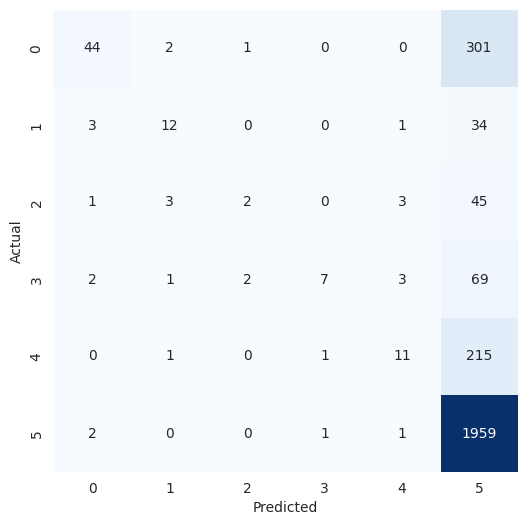

Classification Report:
-------------------
               precision    recall  f1-score   support

           0       0.85      0.13      0.22       348
           1       0.63      0.24      0.35        50
           2       0.40      0.04      0.07        54
           3       0.78      0.08      0.15        84
           4       0.58      0.05      0.09       228
           5       0.75      1.00      0.85      1963

    accuracy                           0.75      2727
   macro avg       0.66      0.26      0.29      2727
weighted avg       0.74      0.75      0.66      2727



In [184]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:\n-------------------\n', clr)

# RandomForestClassifier (With HyperParameter)

In [185]:
# param_grid = {
#    'n_estimators': [100,200],
#    'max_depth': [10, 15],
#    'criterion':['gini','entropy'],
#    'min_samples_split': [5, 10],
#    'min_samples_leaf': [2, 4]
# }
# grid_search = GridSearchCV(rfc, param_grid, cv=5, scoring='accuracy',verbose=2, n_jobs=-1)
# grid_search.fit(X_train_combined, y_train)

# print("Best Parameters:", grid_search.best_params_)
# print("Best Score:", grid_search.best_score_)

In [186]:
rfchp=RandomForestClassifier(n_estimators = 100,
                             min_samples_split = 5,
                             min_samples_leaf = 2,
                             max_depth = 15,
                             criterion = 'entropy')
rfchp.fit(X_train_combined,y_train)

RandomForestClassifier(criterion='entropy', max_depth=15, min_samples_leaf=2,
                       min_samples_split=5)

In [187]:
print('Traning Score:', rfchp.score(X_train_combined,y_train))

Traning Score: 0.770697717062437


In [188]:
y_pred = rfchp.predict(X_test_combined)
print('Testing Score:',rfchp.score(X_test_combined,y_test))

Testing Score: 0.7198386505317198


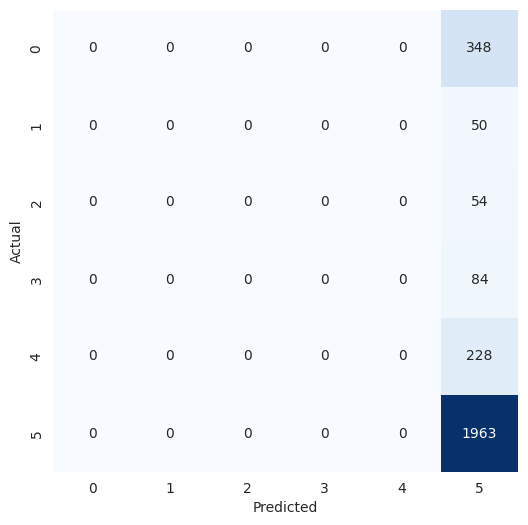

Classification Report:RandomForestClassifier
-------------------
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       348
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00        54
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00       228
           5       0.72      1.00      0.84      1963

    accuracy                           0.72      2727
   macro avg       0.12      0.17      0.14      2727
weighted avg       0.52      0.72      0.60      2727



In [189]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:RandomForestClassifier\n-------------------\n', clr)

# HistGradientBoostingClassifier

In [190]:
clf=HistGradientBoostingClassifier()
clf.fit(X_train_combined,y_train)

HistGradientBoostingClassifier()

In [191]:
print('Training Score:',clf.score(X_train_combined,y_train))

Training Score: 0.883010910424498


In [192]:
y_pred = clf.predict(X_test_combined)
print('Testing Score:',clf.score(X_test_combined,y_test))

Testing Score: 0.731939860652732


In [193]:
y_score_clf=clf.predict_proba(X_test_combined)
y_score_clf

array([[5.17351678e-02, 7.98423482e-04, 9.83612459e-04, 4.10587908e-03,
        1.61551020e-01, 7.80825898e-01],
       [2.01843983e-02, 1.58442005e-04, 2.06866024e-04, 9.87286179e-04,
        5.42950253e-02, 9.24167982e-01],
       [5.44113928e-02, 7.76754765e-01, 7.90448471e-02, 3.13918615e-02,
        2.87766443e-02, 2.96204892e-02],
       ...,
       [5.75328596e-02, 1.06961773e-03, 7.19439258e-03, 4.30613263e-02,
        4.09548165e-01, 4.81593639e-01],
       [1.71124287e-02, 3.80315105e-04, 3.03843463e-03, 4.14884748e-03,
        3.16360811e-02, 9.43683893e-01],
       [3.21057864e-01, 6.49608691e-02, 2.54740886e-03, 1.18914693e-01,
        2.65325917e-01, 2.27193248e-01]])

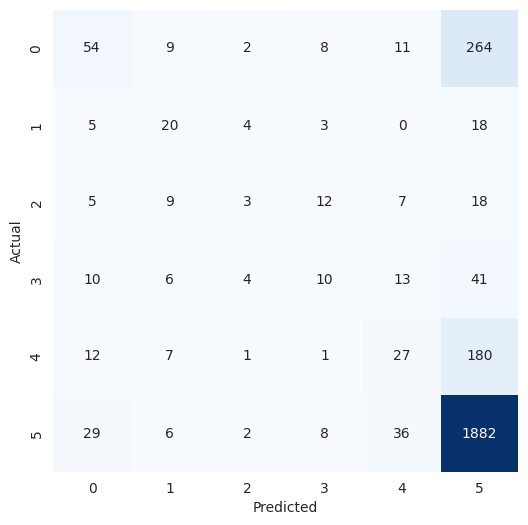

Classification Report: GradientBoostingClassifier
-------------------
               precision    recall  f1-score   support

           0       0.47      0.16      0.23       348
           1       0.35      0.40      0.37        50
           2       0.19      0.06      0.09        54
           3       0.24      0.12      0.16        84
           4       0.29      0.12      0.17       228
           5       0.78      0.96      0.86      1963

    accuracy                           0.73      2727
   macro avg       0.39      0.30      0.31      2727
weighted avg       0.67      0.73      0.68      2727



In [194]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report: GradientBoostingClassifier\n-------------------\n', clr)

# XG Boost

In [195]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train_combined,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [196]:
print("Traning score:",xgb.score(X_train_combined,y_train))

Traning score: 0.9085908132392042


In [197]:
y_pred = xgb.predict(X_test_combined)
print("Testing score:",xgb.score(X_test_combined,y_test))

Testing score: 0.7425742574257426


In [198]:
y_score_xgb=xgb.predict_proba(X_test_combined)
y_score_xgb

array([[7.0278153e-02, 1.2566445e-03, 1.4743272e-03, 6.8157245e-03,
        1.8011436e-01, 7.4006081e-01],
       [5.4278360e-03, 2.2413270e-04, 2.7408762e-05, 4.7744892e-04,
        1.3511829e-02, 9.8033136e-01],
       [1.0373776e-02, 9.2464429e-01, 3.4100708e-02, 1.7823827e-02,
        8.7259999e-03, 4.3314067e-03],
       ...,
       [1.6397288e-01, 4.0586252e-04, 3.2973837e-03, 4.7099710e-02,
        3.7477261e-01, 4.1045156e-01],
       [2.8192973e-02, 2.3901658e-03, 1.1958907e-02, 2.9994119e-02,
        2.6065312e-02, 9.0139860e-01],
       [2.2799371e-01, 7.3833488e-02, 3.0241318e-03, 1.0444902e-01,
        4.2757559e-01, 1.6312410e-01]], dtype=float32)

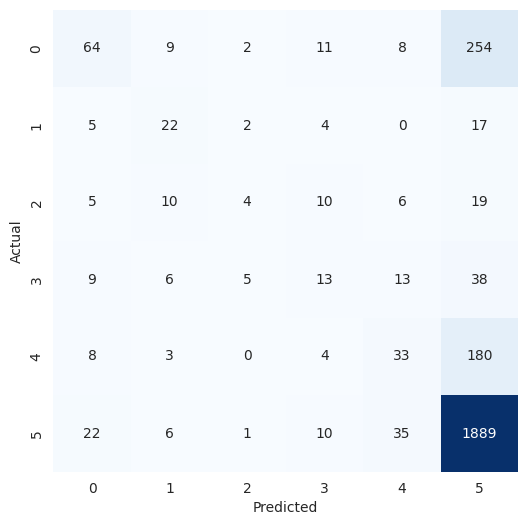

Classification Report:XGBoostClassifier
-------------------
               precision    recall  f1-score   support

           0       0.57      0.18      0.28       348
           1       0.39      0.44      0.42        50
           2       0.29      0.07      0.12        54
           3       0.25      0.15      0.19        84
           4       0.35      0.14      0.20       228
           5       0.79      0.96      0.87      1963

    accuracy                           0.74      2727
   macro avg       0.44      0.33      0.35      2727
weighted avg       0.69      0.74      0.69      2727



In [199]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:XGBoostClassifier\n-------------------\n', clr)

# Acurracy of Models

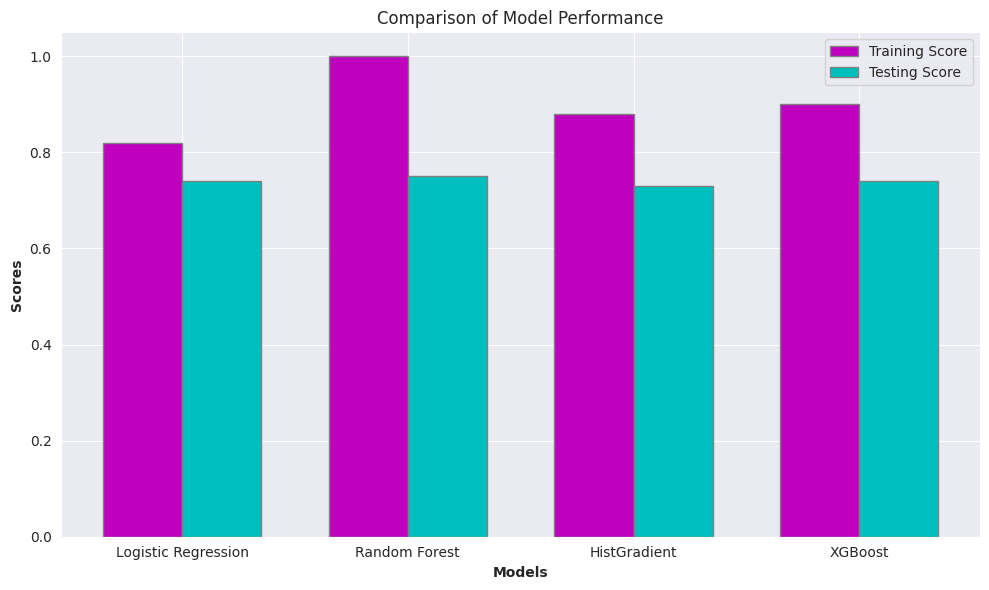

In [200]:
import matplotlib.pyplot as plt  # accuracy with oot(out of time validation)

models = ['Logistic Regression', 'Random Forest', 'HistGradient','XGBoost']
training_scores = [0.82, 1, 0.88, 0.90]
testing_scores = [0.74, 0.75, 0.73, 0.74]

bar_width = 0.35

r1 = range(len(models))
r2 = [x + bar_width for x in r1]

plt.figure(figsize=(10, 6))
plt.bar(r1, training_scores, color='m', width=bar_width, edgecolor='grey', label='Training Score')
plt.bar(r2, testing_scores, color='c', width=bar_width, edgecolor='grey', label='Testing Score')

plt.xlabel('Models', fontweight='bold')
plt.ylabel('Scores', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(models))], models)
plt.title('Comparison of Model Performance')
plt.legend()

plt.tight_layout()
plt.show()


# ROC

In [201]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
y_onehot_test.shape  # (n_samples, n_classes)

(2727, 6)

In [202]:
label_binarizer.transform([3])

array([[0, 0, 0, 1, 0, 0]])

In [203]:
classes = label_binarizer.classes_
classes

array([0, 1, 2, 3, 4, 5])

In [204]:
model_names=['LogisticRegression', 'RandomForest', 'HistGradientBoosting', 'XGBoost']

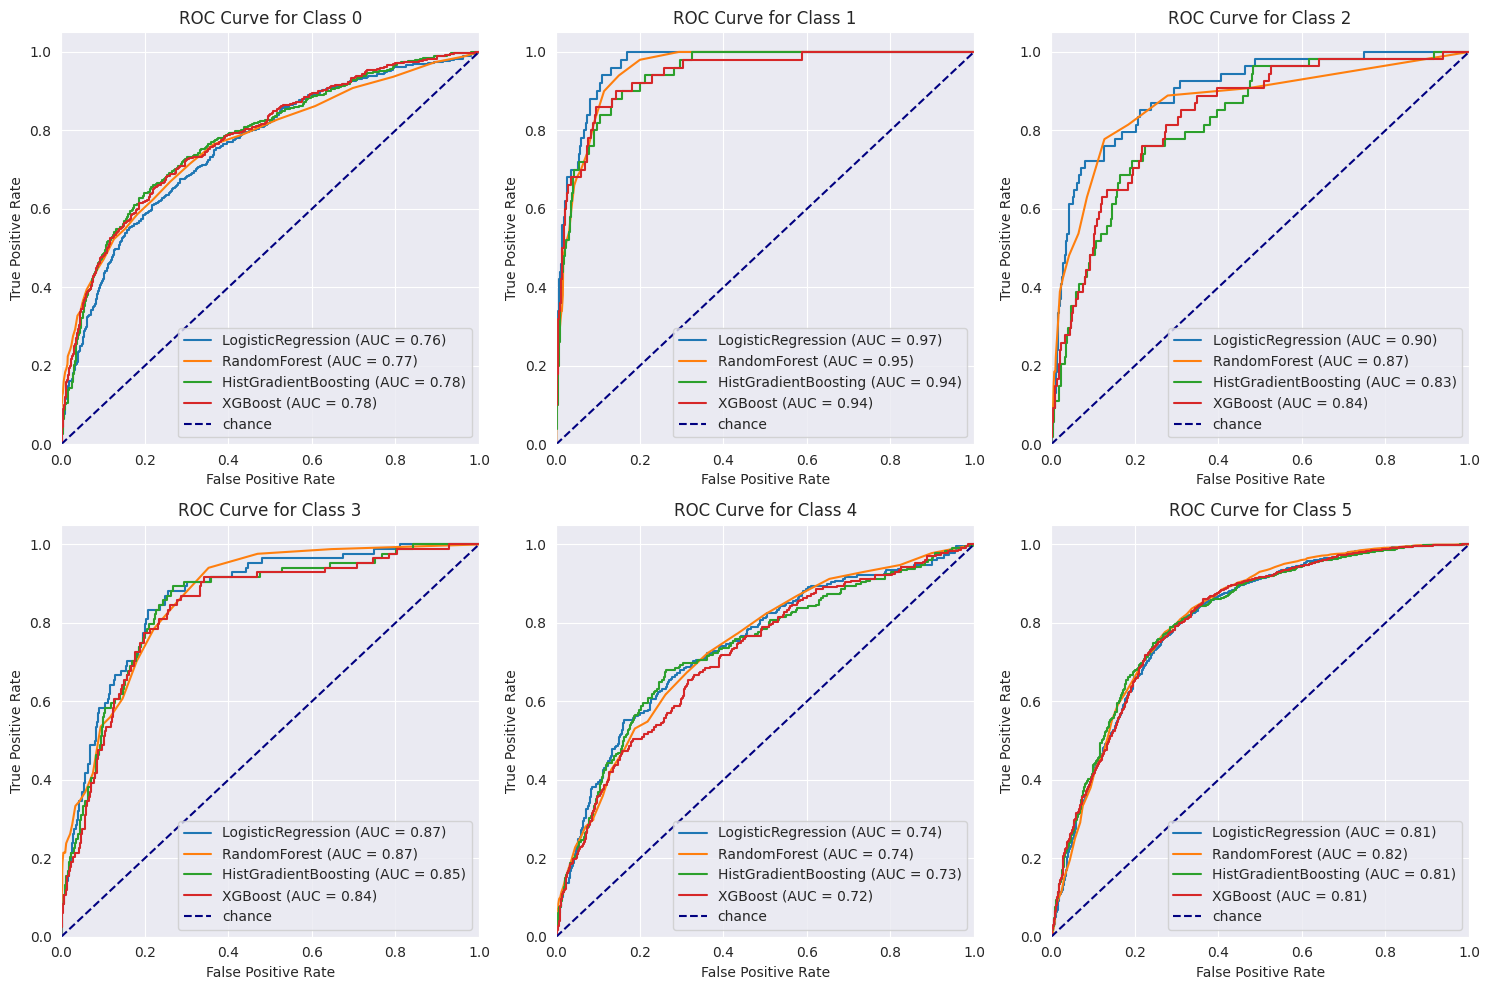

In [205]:
def plot_roc_curves_for_classes(y_train, y_scores_list, classes, model_names):
    # Compute the number of rows and columns for subplots
    num_plots = len(classes)
    num_cols = min(num_plots, 3)  # Display 3 plots per row
    num_rows = (num_plots + num_cols - 1) // num_cols

    # Create subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axs = axs.flatten()  # Flatten the 2D array of subplots to simplify indexing

    # Iterate over each class
    for i, class_label in enumerate(classes):
        # Select the appropriate subplot
        ax = axs[i]

        # Iterate over each model and plot its ROC curve for the current class
        for model_name, y_scores in zip(model_names, y_scores_list):
            fpr, tpr, _ = roc_curve(y_onehot_test[:, i], y_scores[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')


        ax.plot([0, 1], [0, 1], color='navy', linestyle='--', label='chance')


        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curve for Class {class_label}')
        ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

plot_roc_curves_for_classes(y_train, [y_score_lr, y_score_rfc, y_score_clf, y_score_xgb], classes, ['LogisticRegression', 'RandomForest', 'HistGradientBoosting', 'XGBoost'])
